## IMPLEMENTING SELF ATTENTION WITH TRAINABLE WEIGHTS

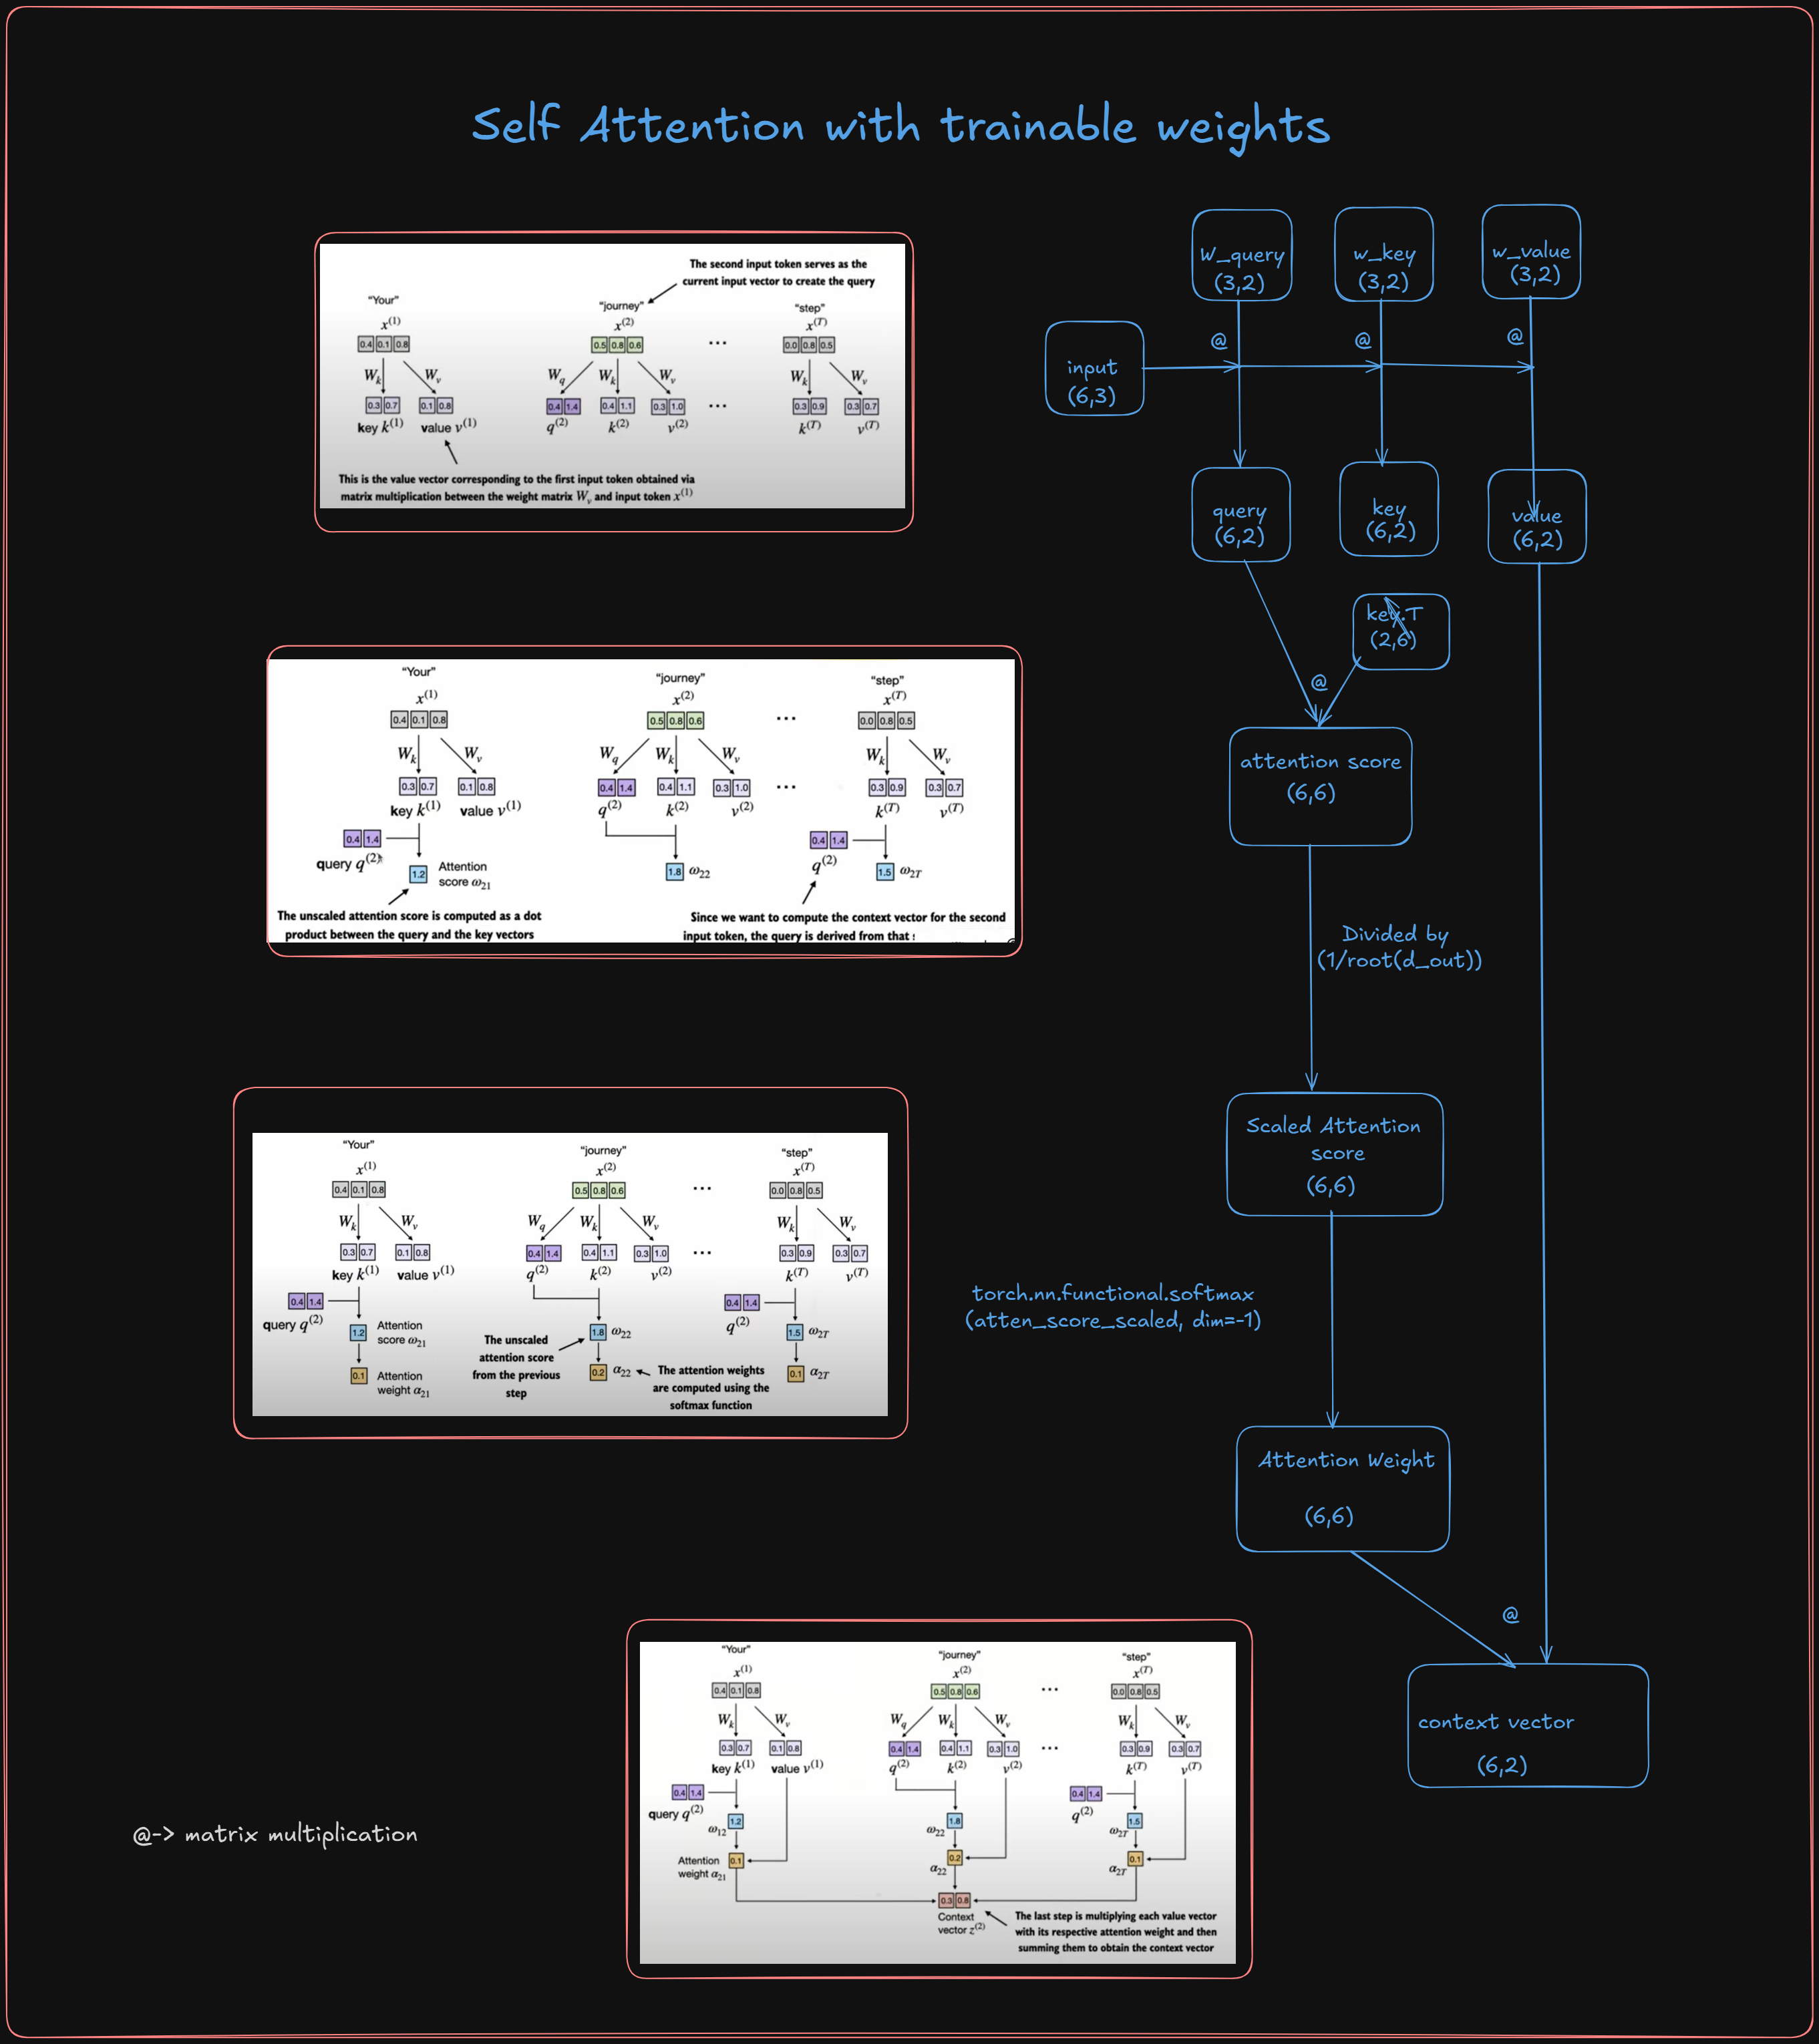

In [1]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

<div class="alert alert-block alert-info">
    
A The second input element(journey)

B The input embedding size, d=3

C The output embedding size, d_out=2

</div>

In [2]:
x_2 = inputs[1]  # A =(1,3)
d_in = inputs.shape[1]  # B = 3
d_out = 2  # C

<div class="alert alert-block alert-info">
In GPT-like models, the input and output dimensions are usually the same. 

But here ,we choose different input (d_in=3) and output (d_out=2) dimensions here.
</div>

In [3]:
torch.manual_seed(123)
w_query = torch.nn.Parameter(torch.rand(d_in,d_out), requires_grad = False) # (3,2)
w_key =  torch.nn.Parameter(torch.rand(d_in,d_out), requires_grad = False) # (3,2)
w_value = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad = False) # (3,2)


In [4]:
print("w_query = ", w_query)
print("w_key = ", w_key)
print("w_value = ", w_value)

w_query =  Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])
w_key =  Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])
w_value =  Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]])


In [5]:
query_2 = x_2 @ w_query  # (1,2)
key_2 = x_2 @ w_key      # (1,2)
value_2 = x_2 @ w_value  # (1,2)
print("query_2 = ", query_2)

query_2 =  tensor([0.4306, 1.4551])


<div class="alert alert-block alert-info">
    
As we can see based on the output for the query, this results in a 2-dimensional vector. 

This is because: we set the number of columns of the corresponding weight matrix, via d_out, to 2:

</div>

<div class="alert alert-block alert-success">

Next, we compute the query, key, and value vectors of the input vector
</div>

<div class="alert alert-block alert-warning">
<div>
    <b> Query </b> -> Analogous to search query in a database . It represents the current token the model focus on.
</div> 
<div>
    <b> Key </b> -> In attention mechanism , each item in  

</div>

<div class="alert alert-block alert-success">
Step - 1 : Calculate query , key and value by multiplying inputs with w_query, w_key,w_value respectively.
</div>

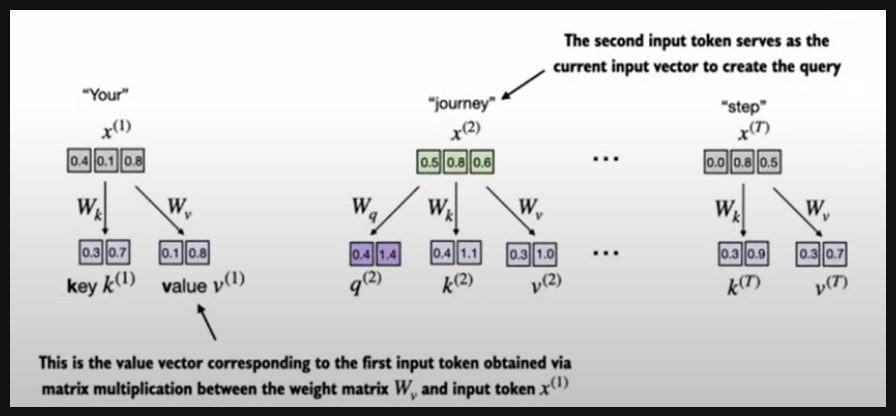

In [6]:
query = inputs @ w_query  # (6,2)
key = inputs @ w_key      # (6,2)
value = inputs @ w_value  # (6,2)
print("query = ", query)
print("key = ", key)

query =  tensor([[0.2309, 1.0966],
        [0.4306, 1.4551],
        [0.4300, 1.4343],
        [0.2355, 0.7990],
        [0.2983, 0.6565],
        [0.2568, 1.0533]])
key =  tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]])


<div class="alert alert-block alert-success">
Step - 2  Here we will calculate attention scores , by multiplying query with key's transpose .
</div>


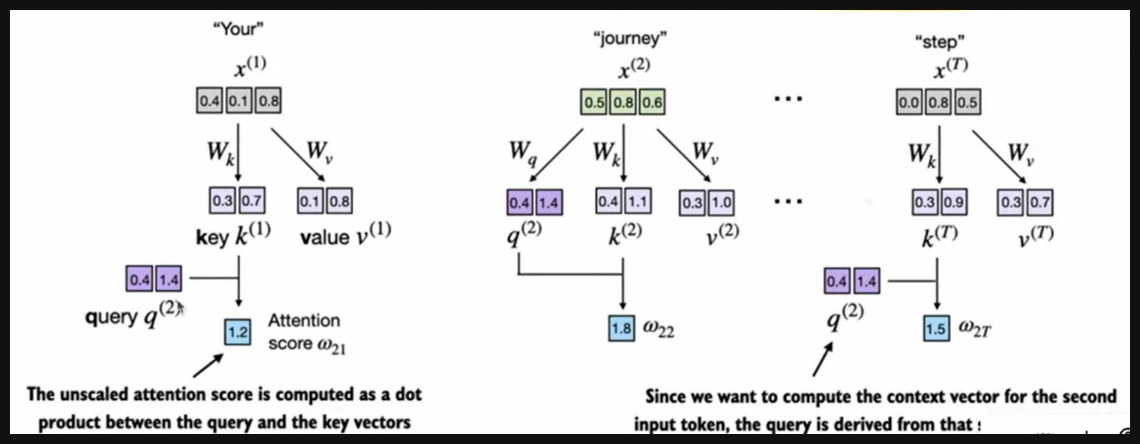

In [7]:
atten_score_2 = query_2 @ key.T  # (1,2)@(2,6) = (1,6)
print("atten_score_2 = ", atten_score_2)
atten_score =query@key.T  # (6,2)@(2,6) = (6,6)
print("atten_score = ", atten_score)

atten_score_2 =  tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])
atten_score =  tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]])


<div class="alert alert-block alert-success">
Step - 3 : divide them Root dimension times before using softmax .
</div>



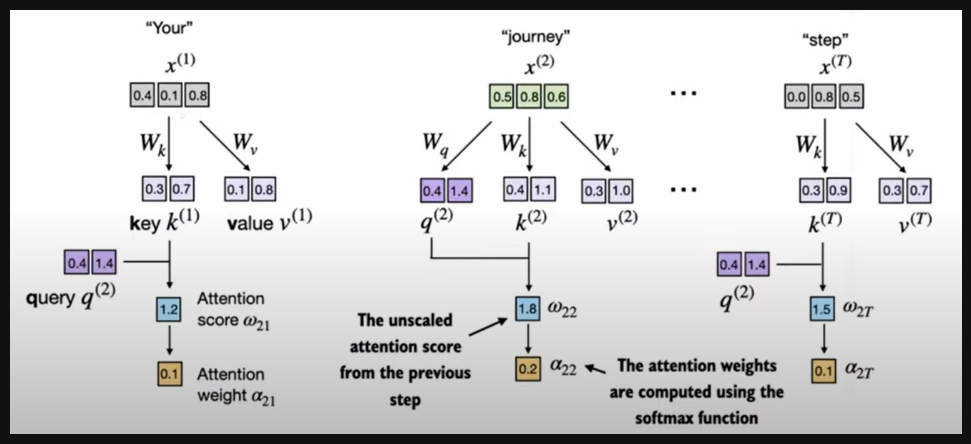

In [8]:
atten_score_2_scaled = atten_score_2 / (d_out**0.5)  # (1,6)
atten_score_scaled = atten_score / (d_out**0.5)  # (6,6)
print("atten_score_2_scaled = ", atten_score_2_scaled)
print("atten_score_scaled = ", atten_score_scaled)

atten_score_2_scaled =  tensor([0.8984, 1.3098, 1.2806, 0.7633, 0.3944, 1.0918])
atten_score_scaled =  tensor([[0.6528, 0.9578, 0.9363, 0.5593, 0.2851, 0.8011],
        [0.8984, 1.3098, 1.2806, 0.7633, 0.3944, 1.0918],
        [0.8870, 1.2929, 1.2641, 0.7534, 0.3895, 1.0775],
        [0.4930, 0.7189, 0.7029, 0.4190, 0.2164, 0.5993],
        [0.4323, 0.6236, 0.6099, 0.3621, 0.1914, 0.5167],
        [0.6361, 0.9309, 0.9101, 0.5432, 0.2784, 0.7776]])


In [9]:
atten_weights_2 = torch.nn.functional.softmax(atten_score_2_scaled, dim=-1)  # (1,6)
atten_weights = torch.nn.functional.softmax(atten_score_scaled, dim=-1)  # (6,6)

In [10]:
print("atten_weights_2 = ", atten_weights_2)
print("atten_weights = ", atten_weights)

atten_weights_2 =  tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])
atten_weights =  tensor([[0.1551, 0.2104, 0.2059, 0.1413, 0.1074, 0.1799],
        [0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820],
        [0.1503, 0.2256, 0.2192, 0.1315, 0.0914, 0.1819],
        [0.1591, 0.1994, 0.1962, 0.1477, 0.1206, 0.1769],
        [0.1610, 0.1949, 0.1923, 0.1501, 0.1265, 0.1752],
        [0.1557, 0.2092, 0.2048, 0.1419, 0.1089, 0.1794]])


<div class="alert alert-block alert-success">
Step - 4 :Multiply attention weight with value to get the context vector .
</div>



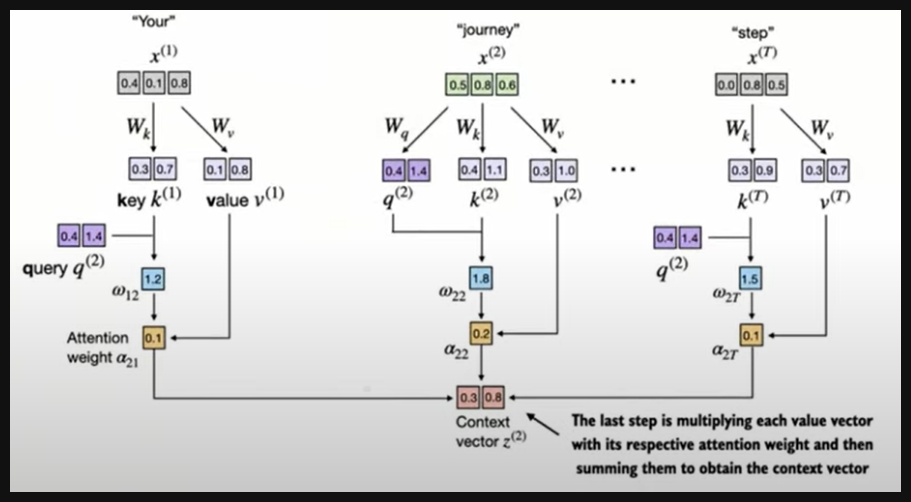

In [11]:
context_2 = atten_weights_2 @ value  # (1,6)@(6,2) = (1,2)
context = atten_weights @ value  # (6,6)@(6,2) = (6,2)
print("context_2 = ", context_2)
print("context = ", context)

context_2 =  tensor([0.3061, 0.8210])
context =  tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]])


## IMPLEMENTING A COMPACT SELF ATTENTION PYTHON CLASS USING **PARAMETER**

<div class="alert alert-block alert-success">
    
In the previous sections, we have gone through a lot of steps to compute the self-attention
outputs. 

This was mainly done for illustration purposes so we could go through one step at
a tim. 

In practice, with the LLM implementation in the next chapter in mind, it is helpful to
organize this code into a Python class as follows:
    
</div>

In [12]:
class SelfAttention_v1(torch.nn.Module):
    def __init__(self,d_in,d_out):
        super().__init__()
        self.w_query = torch.nn.Parameter(torch.rand(d_in,d_out), requires_grad = False)
        self.w_key = torch.nn.Parameter (torch.rand(d_in,d_out), requires_grad = False)
        self.w_value = torch.nn.Parameter(torch.rand(d_in,d_out), requires_grad = False)
    def forword(self,x):
        query = x@ self.w_query
        key = x@ self.w_key
        value = x@ self.w_value

        atten_score = query@key.T
        atten_score_scaled = atten_score / (d_out**0.5)
        atten_weights = torch.nn.functional.softmax(atten_score_scaled, dim=-1)
        context = atten_weights@value
        return context

<div class="alert alert-block alert-warning">

The __init__ method initializes trainable weight matrices (W_query, W_key, and
W_value) for queries, keys, and values, each transforming the input dimension d_in to an
output dimension d_out.

</div>

<div class="alert alert-block alert-warning">

During the forward pass, using the forward method, we compute the attention scores
(attn_scores) by multiplying queries and keys, normalizing these scores using softmax.

</div>

<div class="alert alert-block alert-success">
    
Finally, we create a context vector by weighting the values with these normalized attention
scores.
    
</div>

In [13]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in,d_out)
context_v1 = sa_v1.forword(inputs)
print("context_v1 = ", context_v1)

context_v1 =  tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]])


<div class="alert alert-block alert-info">

Since inputs contains six embedding vectors, we get a matrix storing the six
context vectors, as shown in the above result. 
</div>

## IMPLEMENTING A COMPACT SELF ATTENTION PYTHON CLASS USING **LINEAR**

<div class="alert alert-block alert-warning">

We can improve the SelfAttention_v1 class  implementation further by utilizing PyTorch's
nn.Linear layers, which effectively perform matrix multiplication when the bias units are
disabled. 

</div>

<div class="alert alert-block alert-warning">

Additionally, a significant advantage of using nn.Linear instead of manually
implementing nn.Parameter(torch.rand(...)) is that nn.Linear has an optimized weight
initialization scheme, contributing to more stable and effective model training.

</div>

In [14]:
class SelfAttention_v2(torch.nn.Module):
    def __init__(self,d_in,d_out,bias = False):
        super().__init__()
        self.w_query = torch.nn.Linear(d_in,d_out,bias=bias)
        self.w_key = torch.nn.Linear(d_in,d_out,bias=bias)
        self.w_value = torch.nn.Linear(d_in,d_out,bias=bias)
    def forword(self,x):
        # in paramter we are using x @ w_query but in linear we are using w_query(x) as 
        # linear means y = x@W + b and here bias =0 
        query = self.w_query(x) 
        key = self.w_key(x)
        value = self.w_value(x)

        atten_score = query @ key.T 
        atten_score_scaled = atten_score / (d_out**0.5)
        atten_weights = torch.nn.functional.softmax(atten_score_scaled, dim=-1)
        context = atten_weights @ value
        return context


In [15]:
torch.manual_seed(123)
sa_v2 = SelfAttention_v2(d_in,d_out,bias=False)
context_v2 = sa_v2.forword(inputs)
print("context_v2 = ", context_v2)

context_v2 =  tensor([[-0.5337, -0.1051],
        [-0.5323, -0.1080],
        [-0.5323, -0.1079],
        [-0.5297, -0.1076],
        [-0.5311, -0.1066],
        [-0.5299, -0.1081]], grad_fn=<MmBackward0>)


<div class="alert alert-block alert-info">

Note that SelfAttention_v1 and SelfAttention_v2 give different outputs because they
use different initial weights for the weight matrices since nn.Linear uses a more
sophisticated weight initialization scheme.
    
</div>

## Why to divide by SQRT(Dimention)

<div class="alert alert-block alert-warning">

Reason 1: For stability in learning

The softmax function is sensitive to the magnitudes of its inputs. When the inputs are large, the differences between the exponential values of each input become much more pronounced. This causes the softmax output to become "peaky," where the highest value receives almost all the probability mass, and the rest receive very little.

In attention mechanisms, particularly in transformers, if the dot products between query and key vectors become too large (like multiplying by 8 in this example), the attention scores can become very large. This results in a very sharp softmax distribution, making the model overly confident in one particular "key." Such sharp distributions can make learning unstable,
    
</div>

In [16]:
import torch

# Define the tensor
tensor = torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])

# Apply softmax without scaling
softmax_result = torch.softmax(tensor, dim=-1)
print("Softmax without scaling:", softmax_result)

# Multiply the tensor by 8 and then apply softmax
scaled_tensor = tensor * 8
softmax_scaled_result = torch.softmax(scaled_tensor, dim=-1)
print("Softmax after scaling (tensor * 8):", softmax_scaled_result)

Softmax without scaling: tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])
Softmax after scaling (tensor * 8): tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])


## BUT WHY SQRT?

<div class="alert alert-block alert-warning">

Reason 2: To make the variance of the dot product stable

The dot product of  Q and K increases the variance because multiplying two random numbers increases the variance.

The increase in variance grows with the dimension. 

Dividing by sqrt (dimension) keeps the variance close to 1
    
</div>

In [17]:
import numpy as np

# Function to compute variance before and after scaling
def compute_variance(dim, num_trials=1000):
    dot_products = []
    scaled_dot_products = []

    # Generate multiple random vectors and compute dot products
    for _ in range(num_trials):
        q = np.random.randn(dim)
        k = np.random.randn(dim)
        
        # Compute dot product
        dot_product = np.dot(q, k)
        dot_products.append(dot_product)
        
        # Scale the dot product by sqrt(dim)
        scaled_dot_product = dot_product / np.sqrt(dim)
        scaled_dot_products.append(scaled_dot_product)
    
    # Calculate variance of the dot products
    variance_before_scaling = np.var(dot_products)
    variance_after_scaling = np.var(scaled_dot_products)

    return variance_before_scaling, variance_after_scaling

# For dimension 5
variance_before_5, variance_after_5 = compute_variance(5)
print(f"Variance before scaling (dim=5): {variance_before_5}")
print(f"Variance after scaling (dim=5): {variance_after_5}")

# For dimension 100
variance_before_100, variance_after_100 = compute_variance(100)
print(f"Variance before scaling (dim=100): {variance_before_100}")
print(f"Variance after scaling (dim=100): {variance_after_100}")



Variance before scaling (dim=5): 5.046267034845975
Variance after scaling (dim=5): 1.009253406969195
Variance before scaling (dim=100): 104.17785744093959
Variance after scaling (dim=100): 1.041778574409396
